#   Phase 2: Data Engineering & Label Strategy
##  Project: Kataoka Inc. Predictive Maintenance System

---

## Business Context

Before we can train any machine learning model, we need to construct
a clean, analysis-ready dataset with a reliable target variable.

In this project, the primary target variable is **Remaining Useful Life (RUL)**.
RUL represents how many hours remain before a robot component fails.
It is computed only for robots with confirmed failure events.

This notebook covers:
- Safe joining of robot metadata to sensor readings
- RUL label creation for confirmed failure robots only
- Censored robot flagging, no fake labels assigned to unobserved failures
- Cumulative operating hours per robot computed from actual timestamps
- Aggregate maintenance features using counts and totals only
- Health risk label creation derived from RUL thresholds, not sensor rules
- Full validation of every join and label assignment
- Output of two processed datasets for downstream modelling

---

## Modelling Strategy Established in This Phase

After careful analysis of the data, two important decisions were made:

**Decision 1: RUL regression is the foundation.**
The model predicts time to failure in hours. Health risk classification
is derived from predicted RUL at inference time, not trained separately.
This keeps the system coherent and avoids fabricating training labels.

**Decision 2: Censored robots are not labelled.**
33 of 50 robots have no confirmed failure event. Assigning health labels
to these robots based on sensor thresholds would teach the model invented
rules rather than real failure patterns. They are flagged as
censored_unlabelled and reserved for inference only after training.

---

## Critical Rules

- The failure table is joined on robot_id only, never broadcast across time
- The maintenance table has no timestamps, so only aggregate features are used
- A blind merge on robot_id would duplicate sensor rows and corrupt RUL values
- Every join is validated with a row count assertion before and after
- No label is assigned without a confirmed failure timestamp as its source

---

In [111]:
# Import the main libraries needed for data analysis.
# pandas helps us work with tables.
# numpy supports numerical calculations.
# matplotlib and seaborn help us create charts for visual analysis.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Load Raw Data
# Each dataset is loaded fresh. Timestamps are parsed on load.
# Maintenance logs have no timestamp column so no parse_dates needed.

robot_df       = pd.read_csv("../data/raw/robot_units.csv", parse_dates=["installation_date"])

sensor_df      = pd.read_csv("../data/raw/sensor_readings.csv", parse_dates=["timestamp"])

maintenance_df = pd.read_csv("../data/raw/maintenance_logs.csv")

failure_df     = pd.read_csv("../data/raw/failure_events.csv", parse_dates=["failure_time"])

print("All datasets loaded successfully.")
print(f"robot_df       : {robot_df.shape}")
print(f"sensor_df      : {sensor_df.shape}")
print(f"maintenance_df : {maintenance_df.shape}")
print(f"failure_df     : {failure_df.shape}")

All datasets loaded successfully.
robot_df       : (50, 5)
sensor_df      : (76730, 7)
maintenance_df : (262, 5)
failure_df     : (17, 5)


## Section 2: Safe Join of Robot Metadata to Sensor Readings

We join robot metadata (model type, factory location, operating environment)
to the sensor readings table using robot_id.

This is a many-to-one join:
- sensor_df has many rows per robot
- robot_df has exactly one row per robot

We validate before and after to confirm no rows were duplicated or dropped.
A silent row count change here would corrupt every downstream calculation.

In [112]:
# Validate join safety before merging 
# Confirm robot_df has exactly one row per robot_id before joining.
# If duplicates exist, the join would multiply sensor rows silently.
robot_id_counts = robot_df["robot_id"].value_counts()
assert robot_id_counts.max() == 1, "robot_df has duplicate robot_ids. Join is unsafe."
print(f"robot_df: {robot_df['robot_id'].nunique()} unique robots. No duplicates. Safe to join.")

rows_before = len(sensor_df)

# Perform the join
# We bring in only the metadata columns needed for modelling.
# installation_date is excluded because cumulative hours will be computed
# directly from sensor timestamps, which is more precise.

robot_meta_cols = ["robot_id", "model_type", "factory_location", "operating_environment"]

merged_df = sensor_df.merge(
    robot_df[robot_meta_cols],
    on="robot_id",
    how="left"
)

rows_after = len(merged_df)

# Validate row count integrity
assert rows_before == rows_after, (
    f"Row count changed after merge. Before: {rows_before}, After: {rows_after}."
)

print(f"Rows before join : {rows_before}")
print(f"Rows after join  : {rows_after}")
print(f"Row count intact : True")
print(f"\nColumns added: {[c for c in merged_df.columns if c not in sensor_df.columns]}")
print(f"\nSample:")
display(merged_df.head(5))

robot_df: 50 unique robots. No duplicates. Safe to join.
Rows before join : 76730
Rows after join  : 76730
Row count intact : True

Columns added: ['model_type', 'factory_location', 'operating_environment']

Sample:


,reading_id,robot_id,timestamp,vibration_level,motor_temperature,torque_load,power_consumption,model_type,factory_location,operating_environment
0,READ-000001,ROB-0001,2023-01-07 00:00:00,0.29,70.10,136.10,1471.00,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
1,READ-000002,ROB-0001,2023-01-07 06:00:00,0.14,70.20,139.50,811.10,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
2,READ-000003,ROB-0001,2023-01-07 12:00:00,0.28,47.90,123.50,752.50,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
3,READ-000004,ROB-0001,2023-01-07 18:00:00,0.17,58.20,111.20,610.90,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"
4,READ-000005,ROB-0001,2023-01-08 00:00:00,0.47,52.80,68.20,1234.00,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)"


## Section 3: Cumulative Operating Hours Per Robot

Cumulative operating hours measures how long each robot has been running
from its first sensor reading up to each individual reading.

This is one of the most important features for RUL prediction.
A robot that has accumulated 5,000 hours behaves differently from one
at 500 hours even if their current sensor readings look identical.

We compute this from actual sensor timestamps rather than assuming
a fixed 6-hour interval. This is more robust and defensible because
it does not depend on the regularity assumption holding perfectly.

Formula:
    cumulative_hours = (timestamp - first_timestamp_for_robot) / 3600 seconds

In [113]:
# Sort by robot and time before computing cumulative hours
# Sorting is mandatory. If rows are out of order, the cumulative
# calculation will produce incorrect values silently.

merged_df = merged_df.sort_values(["robot_id", "timestamp"]).reset_index(drop=True)

# Compute cumulative operating hours from timestamps 
# We use the actual first timestamp per robot as the reference point.
# This avoids assuming a fixed 6-hour interval and is more defensible.

merged_df["cumulative_hours"] = (
    merged_df["timestamp"] -
    merged_df.groupby("robot_id")["timestamp"].transform("min")
).dt.total_seconds() / 3600

# Validate cumulative hours calculation
print("Cumulative Operating Hours Summary")
cum_hours_summary = merged_df.groupby("robot_id")["cumulative_hours"].max()
print(cum_hours_summary.describe().round(1))

print(f"\nMin cumulative hours across fleet  : {cum_hours_summary.min():.0f} hrs")
print(f"Max cumulative hours across fleet  : {cum_hours_summary.max():.0f} hrs")
print(f"Mean cumulative hours across fleet : {cum_hours_summary.mean():.0f} hrs")

print(f"\nSample (first 5 rows for ROB-0001):")
display(merged_df[merged_df["robot_id"] == "ROB-0001"][
    ["robot_id", "timestamp", "cumulative_hours"]
].head(5))

Cumulative Operating Hours Summary
count      50.00
mean     9201.60
std      3152.30
min      2328.00
25%      7164.00
50%     10308.00
75%     11742.00
max     12960.00
Name: cumulative_hours, dtype: float64

Min cumulative hours across fleet  : 2328 hrs
Max cumulative hours across fleet  : 12960 hrs
Mean cumulative hours across fleet : 9202 hrs

Sample (first 5 rows for ROB-0001):


,robot_id,timestamp,cumulative_hours
0,ROB-0001,2023-01-07 00:00:00,0.00
1,ROB-0001,2023-01-07 06:00:00,6.00
2,ROB-0001,2023-01-07 12:00:00,12.00
3,ROB-0001,2023-01-07 18:00:00,18.00
4,ROB-0001,2023-01-08 00:00:00,24.00


## Section 4: RUL Label Creation (Confirmed Failure Robots Only)

RUL (Remaining Useful Life) is calculated as:

    RUL = failure_time - sensor_timestamp (converted to hours)

This calculation is only valid for robots with a confirmed failure event.

For the 33 censored robots (no recorded failure), we cannot assign a
meaningful RUL because we do not know when or if they will fail.
Assigning estimated RUL to censored robots would corrupt training labels
and teach the model fabricated patterns rather than real failure behaviour.

Strategy:
- 17 failure robots  → compute exact RUL from confirmed failure timestamps
- 33 censored robots → RUL remains NaN, flagged as censored_unlabelled
- Remove readings where RUL < 0 (post-failure readings, invalid for training)
- Cap RUL at 8760 hours (one operating year) to prevent extreme outliers

Note on the RUL cap:
8760 hours represents a one-year prediction horizon. This is a modelling
decision that should be confirmed with project stakeholders. Readings
beyond this horizon carry little practical value for maintenance scheduling.


In [114]:
failure_counts = failure_df["robot_id"].value_counts()
assert failure_counts.max() == 1, "Some robots have multiple failure events. RUL labelling needs event-level logic."
print(f"All robots have at most one failure event. Safe to label RUL at robot level.")

All robots have at most one failure event. Safe to label RUL at robot level.


In [115]:
# Step 1: Attach failure time to sensor readings
# Left join on robot_id only.
# Failure robots receive their confirmed failure_time.
# Censored robots receive NaN for failure_time.

confirmed_failure_robots = failure_df["robot_id"].unique()
print(f"Confirmed failure robots : {len(confirmed_failure_robots)}")

rows_before = len(merged_df)

merged_df = merged_df.merge(
    failure_df[["robot_id", "failure_time"]],
    on="robot_id",
    how="left"
)

# Validate row count did not change
assert len(merged_df) == rows_before, "Row count changed during failure join."
print(f"Rows after failure join  : {len(merged_df)}")
print(f"Readings with failure_time (failure robots) : "f"{merged_df['failure_time'].notna().sum()}")
print(f"Readings without failure_time (censored)    : "f"{merged_df['failure_time'].isna().sum()}")

Confirmed failure robots : 17
Rows after failure join  : 76730
Readings with failure_time (failure robots) : 15245
Readings without failure_time (censored)    : 61485


In [116]:
# Step 2: Compute RUL in hours for failure robots only
# RUL = failure_time - timestamp converted to hours.
# For censored robots, failure_time is NaN so RUL will also be NaN.

merged_df["rul_hours_raw"] = np.where(
    merged_df["failure_time"].notna(),
    (merged_df["failure_time"] - merged_df["timestamp"]).dt.total_seconds() / 3600,
    np.nan
)

# Step 3: Remove post-failure readings
# Readings where raw RUL < 0 occurred after the failure event.
# These are invalid for training because the robot had already failed.
# Censored robots have NaN RUL so they are unaffected by this filter.

pre_filter_rows = len(merged_df)

merged_df = merged_df[
    (merged_df["rul_hours_raw"].isna()) | (merged_df["rul_hours_raw"] >= 0)
].copy()

post_filter_rows = len(merged_df)

print(f"Post-failure readings removed : {pre_filter_rows - post_filter_rows}")
print(f"Rows remaining                : {post_filter_rows}")

# Step 4: Cap RUL at 8760 hours
# rul_hours_raw preserves the true calculated RUL.
# rul_hours is the capped modelling target.

RUL_CAP = 8760

merged_df["rul_hours"] = np.where(
    merged_df["rul_hours_raw"].notna(),
    merged_df["rul_hours_raw"].clip(upper=RUL_CAP),
    np.nan
)

print(f"\nRUL cap applied at : {RUL_CAP} hours")
print("\nRaw RUL distribution:")
print(merged_df["rul_hours_raw"].describe().round(1))

print("\nCapped RUL distribution:")
print(merged_df["rul_hours"].describe().round(1))

Post-failure readings removed : 0
Rows remaining                : 76730

RUL cap applied at : 8760 hours

Raw RUL distribution:
count   15245.00
mean     3031.00
std      2029.80
min         0.00
25%      1344.00
50%      2712.00
75%      4512.00
max      8136.00
Name: rul_hours_raw, dtype: float64

Capped RUL distribution:
count   15245.00
mean     3031.00
std      2029.80
min         0.00
25%      1344.00
50%      2712.00
75%      4512.00
max      8136.00
Name: rul_hours, dtype: float64


In [117]:
# Step 5: Flag confirmed failure vs censored robots
# is_failure_robot distinguishes robots with confirmed failure events
# from those with no observed failure within the data window.
# This flag is critical for ensuring censored robots are never used
# as training labels.

merged_df["is_failure_robot"] = merged_df["robot_id"].isin(confirmed_failure_robots)

# Step 6: Label status flag
# label_status makes the distinction explicit for every row.
# labelled_failure_timeline = true RUL label exists, safe for training
# censored_unlabelled       = no confirmed outcome, inference only

merged_df["label_status"] = np.where(merged_df["rul_hours"].notna(), "labelled_failure_timeline", "censored_unlabelled")

print("Label Status Distribution")
print(merged_df["label_status"].value_counts())

print(f"\nFailure vs Censored Robot Coverage")
coverage = merged_df.groupby("is_failure_robot")["robot_id"].nunique()
coverage.index = ["Censored robots", "Confirmed failure robots"]
print(coverage)

Label Status Distribution
label_status
censored_unlabelled          61485
labelled_failure_timeline    15245
Name: count, dtype: int64

Failure vs Censored Robot Coverage
Censored robots             33
Confirmed failure robots    17
Name: robot_id, dtype: int64


## Section 5: RUL Distribution Visualisation

Before moving on, we visualise the RUL label distribution across the
17 confirmed failure robots.

This visualisation answers four specific questions:

1. Are RUL values well spread across the full prediction range,
   or do they cluster in one zone?

2. How many readings fall into each health risk zone?
   Critical, Warning, and Healthy are not equally represented
   in real failure data, and that imbalance has direct modelling consequences.

3. Does any single robot dominate the training data?
   If one robot contributed 80% of all readings, the model would
   learn that robot's behaviour rather than generalising across the fleet.

4. Is the label distribution realistic for a regression problem?
   An extreme skew toward one end of the range signals that special
   handling is needed before training begins.

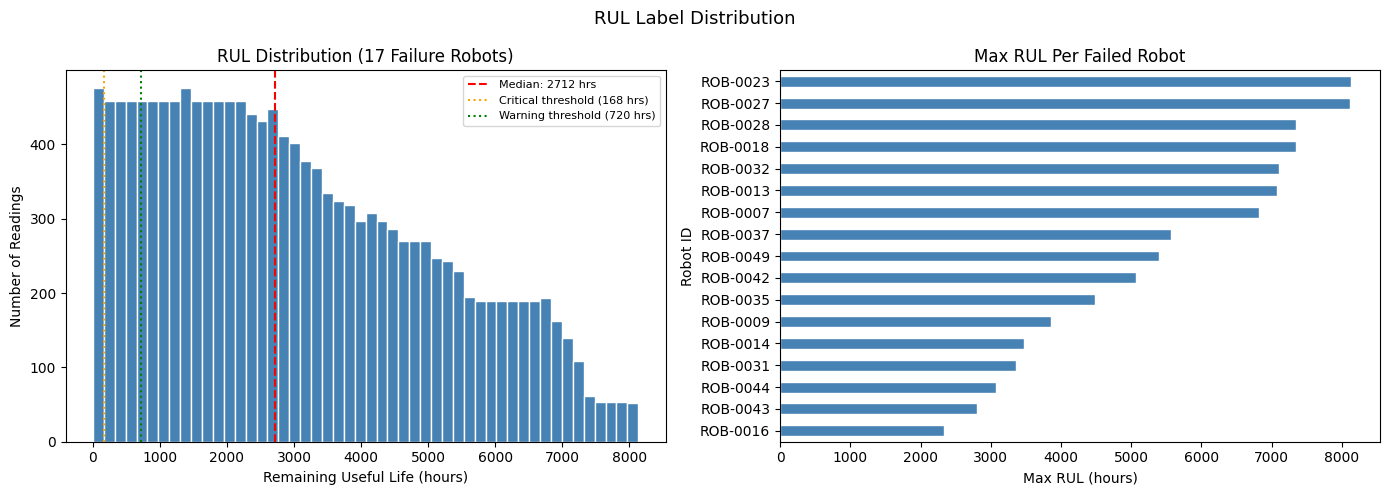


RUL statistics for failure robots:
  Min    : 0 hours
  Max    : 8136 hours
  Mean   : 3031 hours
  Median : 2712 hours

Readings by risk zone:
  Critical (RUL < 168 hrs)      : 476 (3.1%)
  Warning  (168 to 720 hrs)     : 1564 (10.3%)
  Healthy  (RUL > 720 hrs)      : 13205 (86.6%)


In [118]:
# RUL Distribution Visualisation 

rul_data = merged_df[merged_df["is_failure_robot"] == True]["rul_hours"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall RUL distribution
axes[0].hist(rul_data, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(rul_data.median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median: {rul_data.median():.0f} hrs")
axes[0].axvline(168, color="orange", linestyle=":", linewidth=1.5,
                label="Critical threshold (168 hrs)")
axes[0].axvline(720, color="green", linestyle=":", linewidth=1.5,
                label="Warning threshold (720 hrs)")
axes[0].set_title("RUL Distribution (17 Failure Robots)")
axes[0].set_xlabel("Remaining Useful Life (hours)")
axes[0].set_ylabel("Number of Readings")
axes[0].legend(fontsize=8)

# Right: max RUL per failed robot (shows data coverage per robot)
rul_per_robot = (
    merged_df[merged_df["is_failure_robot"] == True]
    .groupby("robot_id")["rul_hours"].max()
    .sort_values()
)

rul_per_robot.plot(kind="barh", ax=axes[1],
                   color="steelblue", edgecolor="white")
axes[1].set_title("Max RUL Per Failed Robot")
axes[1].set_xlabel("Max RUL (hours)")
axes[1].set_ylabel("Robot ID")

plt.suptitle("RUL Label Distribution", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/rul_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nRUL statistics for failure robots:")
print(f"  Min    : {rul_data.min():.0f} hours")
print(f"  Max    : {rul_data.max():.0f} hours")
print(f"  Mean   : {rul_data.mean():.0f} hours")
print(f"  Median : {rul_data.median():.0f} hours")

# Count readings per health risk zone
critical_count = (rul_data < 168).sum()
warning_count  = ((rul_data >= 168) & (rul_data < 720)).sum()
healthy_count  = (rul_data >= 720).sum()

print(f"\nReadings by risk zone:")
print(f"  Critical (RUL < 168 hrs)      : {critical_count} ({critical_count/len(rul_data)*100:.1f}%)")
print(f"  Warning  (168 to 720 hrs)     : {warning_count} ({warning_count/len(rul_data)*100:.1f}%)")
print(f"  Healthy  (RUL > 720 hrs)      : {healthy_count} ({healthy_count/len(rul_data)*100:.1f}%)")

### Key Finding: Class Imbalance and Data Coverage

#### What the distribution shows

The RUL distribution is right-skewed. The majority of labelled readings
represent robots operating far from failure, with a sharp drop-off
as RUL approaches zero.

| Risk Zone | RUL Range | Readings | Share |
|---|---|---|---|
| Healthy | > 720 hours | 13,205 | 86.6% |
| Warning | 168 to 720 hours | 1,564 | 10.3% |
| Critical | < 168 hours | 476 | 3.1% |

This is not a data quality issue. It reflects reality.
Robots spend the majority of their operational life in a healthy state
and only a small window of time approaching failure.

#### Why this matters for modelling

A naive model that predicts "Healthy" for every single reading would
achieve 86.6% accuracy. That model would have zero business value
because it would never flag a robot approaching failure.

This means overall accuracy is not a valid evaluation metric for this project.
We will evaluate model performance segmented by risk zone, with Critical
zone performance treated as the primary business metric.

#### Individual robot coverage

The right chart shows significant variation in data coverage per robot.
ROB-0023 and ROB-0027 each contributed over 8,000 hours of readings,
while ROB-0016 contributed only around 2,300 hours.

This has two implications:

First, the model may over-index on behaviour patterns from robots
with the most data. This will be monitored during evaluation.

Second, when we split by robot_id for train and test in Phase 3,
we must ensure the test set is not accidentally filled with
short-coverage robots, which would make evaluation harder than training.

#### What we will do about this in Phase 3

- Sample weighting applied during training to give Critical zone
  readings proportionally more influence than their 3.1% share suggests
- Evaluation reported separately per risk zone, not just overall
- Train/test split reviewed for data volume balance across robots
- A model that cannot detect Critical zone readings will not be accepted
  regardless of its overall MAE score

#### Stakeholder implication

Kataoka's primary business risk is unplanned downtime caused by
undetected failures. A model optimised only for average accuracy
does not address that risk. Performance in the Critical zone,
the 7 days before failure, is what determines whether this system
delivers real operational value.

## Section 6: Aggregate Maintenance Features

The maintenance table has no timestamp column, confirmed in Phase 1 EDA.
This means we cannot compute time-based features such as
"time since last maintenance."

What we can compute safely from the maintenance table:
- Total maintenance events per robot
- Total downtime hours per robot
- Average downtime per event per robot
- Count of repair events (most severe maintenance type)
- Count of replacement events (component fully replaced)
- Count of calibration events
- Count of inspection events

These aggregate features capture the overall maintenance burden
of each robot and may carry degradation signal.

We join these to merged_df using robot_id only.
This is a safe many-to-one join since aggregates produce one row per robot.
Row count must not change after this join.

In [119]:
# Compute aggregate maintenance features per robot
# We group by robot_id and compute summary statistics.
# Each feature captures a different dimension of maintenance history.

maintenance_agg = maintenance_df.groupby("robot_id").agg(
    total_maintenance_count = ("maintenance_id", "count"),
    total_downtime_hours    = ("downtime_hours", "sum"),
    avg_downtime_hours      = ("downtime_hours", "mean"),
    repair_count            = ("maintenance_type",
                               lambda x: (x == "repair").sum()),
    replacement_count       = ("maintenance_type",
                               lambda x: (x == "replacement").sum()),
    lubrication_count       = ("maintenance_type", 
                               lambda x: (x == "lubrication").sum()),
    calibration_count       = ("maintenance_type",
                               lambda x: (x == "calibration").sum()),
    inspection_count        = ("maintenance_type",
                               lambda x: (x == "inspection").sum()),
).reset_index()

print("Aggregate Maintenance Features")
print(maintenance_agg.describe().round(2))
print(f"\nSample:")
display(maintenance_agg.head(5))

Aggregate Maintenance Features
       total_maintenance_count  total_downtime_hours  avg_downtime_hours  \
count                    50.00                 50.00               50.00   
mean                      5.24                 22.91                4.88   
std                       1.02                 14.18                3.83   
min                       3.00                  8.70                1.58   
25%                       5.00                 11.98                2.20   
50%                       5.00                 16.55                2.78   
75%                       6.00                 27.95                7.22   
max                       7.00                 54.60               16.23   

       repair_count  replacement_count  lubrication_count  calibration_count  \
count         50.00              50.00              50.00              50.00   
mean           0.32               0.18               1.36               1.72   
std            0.47               0.44      

,robot_id,total_maintenance_count,total_downtime_hours,avg_downtime_hours,repair_count,replacement_count,lubrication_count,calibration_count,inspection_count
0,ROB-0001,7,14.40,2.06,0,0,2,1,4
1,ROB-0002,6,11.90,1.98,0,0,2,1,3
2,ROB-0003,5,11.10,2.22,0,0,0,2,3
3,ROB-0004,6,11.90,1.98,0,0,3,1,2
4,ROB-0005,6,11.30,1.88,0,0,3,1,2


In [120]:
# Join maintenance aggregates to merged_df
# Safe many-to-one join. One aggregate row per robot joins to
# many sensor rows per robot. Row count must not change.

rows_before = len(merged_df)

merged_df = merged_df.merge(
    maintenance_agg,
    on="robot_id",
    how="left"
)

rows_after = len(merged_df)

assert rows_before == rows_after, (
    f"Row count changed during maintenance join. "
    f"Before: {rows_before}, After: {rows_after}"
)

print(f"Rows before maintenance join : {rows_before}")
print(f"Rows after maintenance join  : {rows_after}")
print(f"Row count intact             : True")
print(f"\nMaintenance columns added:")
print([c for c in maintenance_agg.columns if c != "robot_id"])
print(f"\nSample after maintenance join:")
display(merged_df.head(5))

Rows before maintenance join : 76730
Rows after maintenance join  : 76730
Row count intact             : True

Maintenance columns added:
['total_maintenance_count', 'total_downtime_hours', 'avg_downtime_hours', 'repair_count', 'replacement_count', 'lubrication_count', 'calibration_count', 'inspection_count']

Sample after maintenance join:


,reading_id,robot_id,timestamp,vibration_level,motor_temperature,torque_load,power_consumption,model_type,factory_location,operating_environment,cumulative_hours,failure_time,rul_hours_raw,rul_hours,is_failure_robot,label_status,total_maintenance_count,total_downtime_hours,avg_downtime_hours,repair_count,replacement_count,lubrication_count,calibration_count,inspection_count
0,READ-000001,ROB-0001,2023-01-07 00:00:00,0.29,70.10,136.10,1471.00,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)",0.00,NaT,NaN,NaN,False,censored_unlabelled,7,14.40,2.06,0,0,2,1,4
1,READ-000002,ROB-0001,2023-01-07 06:00:00,0.14,70.20,139.50,811.10,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)",6.00,NaT,NaN,NaN,False,censored_unlabelled,7,14.40,2.06,0,0,2,1,4
2,READ-000003,ROB-0001,2023-01-07 12:00:00,0.28,47.90,123.50,752.50,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)",12.00,NaT,NaN,NaN,False,censored_unlabelled,7,14.40,2.06,0,0,2,1,4
3,READ-000004,ROB-0001,2023-01-07 18:00:00,0.17,58.20,111.20,610.90,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)",18.00,NaT,NaN,NaN,False,censored_unlabelled,7,14.40,2.06,0,0,2,1,4
4,READ-000005,ROB-0001,2023-01-08 00:00:00,0.47,52.80,68.20,1234.00,ARM-X7,Nagoya Site,"Standard Factory (25-30°C, 60% RH)",24.00,NaT,NaN,NaN,False,censored_unlabelled,7,14.40,2.06,0,0,2,1,4


## Section 7: Health Risk Label Creation

Based on the analysis in Phase 1 EDA and the modelling strategy decision,
health risk labels are derived exclusively from confirmed RUL values.

We do NOT assign health labels to censored robots during this phase.
Censored robots have no confirmed failure timeline and cannot be given
ground truth labels without fabricating data.

Health risk labels for failure robots are defined as:

| Label    | RUL Threshold         | Business Meaning                        |
|----------|-----------------------|-----------------------------------------|
| Critical | RUL < 168 hours       | Failure within 7 days. Immediate action |
| Warning  | 168 to 720 hours      | Failure within 30 days. Schedule soon  |
| Healthy  | RUL > 720 hours       | Normal operation. Continue monitoring  |

Censored robots receive NaN for health_risk_label.
Their label_status column already flags them as censored_unlabelled.

After the RUL regression model is trained in Phase 3, it will be applied
to censored robots to generate predicted RUL values. Health risk labels
will then be derived from those predictions at inference time.
That process produces estimated risk levels, not confirmed ground truth.

In [121]:
# Assign health risk labels based on confirmed RUL only
# Labels are derived from RUL thresholds agreed with the project.
# Censored robots receive NaN because no confirmed failure timeline exists.
# This function is applied only where rul_hours is not NaN.

CRITICAL_THRESHOLD = 168   # hours (7 days before failure)
WARNING_THRESHOLD  = 720   # hours (30 days before failure)

def assign_health_risk_label(rul):
    """
    Assigns a health risk label based on Remaining Useful Life (RUL).

    This function is applied only to robots with confirmed failure events.
    Censored robots are handled separately and receive NaN.

    Parameters:
    -----------
    rul : float
        Remaining Useful Life in hours.

    Returns:
    --------
    str : 'Critical', 'Warning', or 'Healthy'
    """
    if pd.isna(rul):
        return np.nan
    elif rul < CRITICAL_THRESHOLD:
        return "Critical"
    elif rul < WARNING_THRESHOLD:
        return "Warning"
    else:
        return "Healthy"

# Apply to all rows. Censored robots return NaN automatically.
merged_df["health_risk_label"] = merged_df["rul_hours"].apply(assign_health_risk_label)

# Validate label coverage and distribution
print("Health Risk Label Distribution (failure robots only)")
print(merged_df["health_risk_label"].value_counts())

print(f"\nNull labels (censored robots, expected)")
print(f"Null health_risk_label : {merged_df['health_risk_label'].isna().sum()}")

print(f"\nLabel coverage by robot status")
label_coverage = merged_df.groupby("is_failure_robot")["health_risk_label"].value_counts()
print(label_coverage)

Health Risk Label Distribution (failure robots only)
health_risk_label
Healthy     13205
Warning      1564
Critical      476
Name: count, dtype: int64

Null labels (censored robots, expected)
Null health_risk_label : 61485

Label coverage by robot status
is_failure_robot  health_risk_label
True              Healthy              13205
                  Warning               1564
                  Critical               476
Name: count, dtype: int64


## Section 8: Final Dataset Validation

Before saving, we run a full validation pass on the merged dataset.

We confirm:
- Shape is as expected
- All required columns are present
- RUL values exist only for failure robots
- Health risk labels exist only where RUL exists
- Label status covers all 76,730 rows
- No unexpected nulls in critical columns
- All 50 robots from the original sensor table are present

In [122]:
# Final validation checks 

print(" 1. Final Dataset Shape")
print(f"Rows    : {merged_df.shape[0]}")
print(f"Columns : {merged_df.shape[1]}")

print("\n 2. Column List")
for col in merged_df.columns:
    print(f"  {col}")

print("\n 3. Null Value Check (critical columns only)")
critical_cols = [
    "robot_id", "timestamp", "vibration_level", "motor_temperature",
    "torque_load", "power_consumption", "cumulative_hours",
    "is_failure_robot", "label_status"
]
for col in critical_cols:
    null_count = merged_df[col].isnull().sum()
    status = "OK" if null_count == 0 else "WARNING"
    print(f"  {col:<30} nulls: {null_count}  [{status}]")

print("\n 4. RUL Only Present for Failure Robots")
rul_by_status = merged_df.groupby("is_failure_robot")["rul_hours"].apply(
    lambda x: x.notna().sum()
)
rul_by_status.index = ["Censored robots", "Failure robots"]
print(rul_by_status)

print("\n 5. Health Risk Labels Only Where RUL Exists")
label_null = merged_df["health_risk_label"].isna().sum()
rul_null    = merged_df["rul_hours"].isna().sum()
print(f"  Null health_risk_label : {label_null}")
print(f"  Null rul_hours         : {rul_null}")
print(f"  Match                  : {label_null == rul_null}")

print("\n 6. Label Status Coverage")
print(merged_df["label_status"].value_counts())
print(f"  Total rows covered : {merged_df['label_status'].notna().sum()}")

print("\n 7. Robot Coverage")
print(f"  Unique robots in merged_df : {merged_df['robot_id'].nunique()}")
print(f"  Unique robots in sensor_df : {sensor_df['robot_id'].nunique()}")
print(f"  Match                      : "
      f"{merged_df['robot_id'].nunique() == sensor_df['robot_id'].nunique()}")

 1. Final Dataset Shape
Rows    : 76730
Columns : 25

 2. Column List
  reading_id
  robot_id
  timestamp
  vibration_level
  motor_temperature
  torque_load
  power_consumption
  model_type
  factory_location
  operating_environment
  cumulative_hours
  failure_time
  rul_hours_raw
  rul_hours
  is_failure_robot
  label_status
  total_maintenance_count
  total_downtime_hours
  avg_downtime_hours
  repair_count
  replacement_count
  lubrication_count
  calibration_count
  inspection_count
  health_risk_label

 3. Null Value Check (critical columns only)
  robot_id                       nulls: 0  [OK]
  timestamp                      nulls: 0  [OK]
  vibration_level                nulls: 0  [OK]
  motor_temperature              nulls: 0  [OK]
  torque_load                    nulls: 0  [OK]
  power_consumption              nulls: 0  [OK]
  cumulative_hours               nulls: 0  [OK]
  is_failure_robot               nulls: 0  [OK]
  label_status                   nulls: 0  [OK]

 4. RUL

## Section 9: Save Processed Datasets

We save two datasets to data/processed/:

**merged_dataset.csv**
The full dataset containing all 50 robots, all 76,730 sensor readings,
cumulative hours, robot metadata, maintenance aggregates, failure flags,
RUL labels where confirmed, and health risk labels where confirmed.
Censored robots are included with label_status = censored_unlabelled.
This is the master dataset for all downstream phases.

**rul_dataset.csv**
A filtered subset containing only the 17 confirmed failure robots
with valid RUL labels. This is the direct input for RUL regression
training in Phase 3. It contains only rows where label_status =
labelled_failure_timeline.

In [123]:
# Save merged_dataset.csv
# Full dataset: all 50 robots, all readings, all labels and flags.
# This is the master processed file for all downstream phases.

merged_df.to_csv("../data/processed/merged_dataset.csv", index=False)
print(f"merged_dataset.csv saved.")
print(f"  Shape    : {merged_df.shape}")
print(f"  Location : data/processed/merged_dataset.csv")

# Save rul_dataset.csv
# Filtered to confirmed failure robots with valid RUL labels only.
# Used for RUL regression training in Phase 3.

rul_df = merged_df[
    merged_df["label_status"] == "labelled_failure_timeline"
].copy()

rul_df.to_csv("../data/processed/rul_dataset.csv", index=False)
print(f"\nrul_dataset.csv saved.")
print(f"  Shape    : {rul_df.shape}")
print(f"  Robots   : {rul_df['robot_id'].nunique()}")
print(f"  Location : data/processed/rul_dataset.csv")

print(f"\nBoth processed files saved to data/processed/")

import os

print(os.path.exists("../data/processed/merged_dataset.csv"))
print(os.path.exists("../data/processed/rul_dataset.csv"))

merged_dataset.csv saved.
  Shape    : (76730, 25)
  Location : data/processed/merged_dataset.csv

rul_dataset.csv saved.
  Shape    : (15245, 25)
  Robots   : 17
  Location : data/processed/rul_dataset.csv

Both processed files saved to data/processed/
True
True


## Additional Sanity Checks

These checks confirm that the processed datasets preserve robot coverage, factory distribution, model-type coverage, and valid RUL progression for a sample robot.

In [124]:
print(merged_df["robot_id"].nunique())
print(merged_df["factory_location"].value_counts())
print(merged_df["model_type"].value_counts())

50
factory_location
Hokkaido Lab      22147
Nagoya Site       18370
Tokyo Factory     14162
Osaka Plant       13008
Fukuoka Center     9043
Name: count, dtype: int64
model_type
ARM-X7         22291
ARM-X9         18228
ASSEMBLY-A3    15142
CONVEYOR-C2    13625
WELDING-W5      7444
Name: count, dtype: int64


In [125]:
print(rul_df["robot_id"].nunique())
print(rul_df["factory_location"].value_counts())
print(rul_df["model_type"].value_counts())

17
factory_location
Tokyo Factory     4601
Hokkaido Lab      4145
Fukuoka Center    3984
Osaka Plant       2126
Nagoya Site        389
Name: count, dtype: int64
model_type
ARM-X7         6899
ARM-X9         3644
ASSEMBLY-A3    2491
CONVEYOR-C2    2211
Name: count, dtype: int64


In [126]:
print(failure_df.merge(robot_df[["robot_id", "model_type"]], on="robot_id")["model_type"].value_counts())

model_type
ARM-X7         7
ARM-X9         4
CONVEYOR-C2    3
ASSEMBLY-A3    3
Name: count, dtype: int64


In [127]:
rob7 = merged_df[merged_df["robot_id"] == "ROB-0007"][
    ["timestamp", "rul_hours", "health_risk_label"]
].sort_values("timestamp")

print("Early readings:")
display(rob7.head(5))

print("Final readings before failure:")
display(rob7.tail(10))

Early readings:


,timestamp,rul_hours,health_risk_label
11638,2023-02-10 00:00:00,6816.00,Healthy
11639,2023-02-10 06:00:00,6810.00,Healthy
11640,2023-02-10 12:00:00,6804.00,Healthy
11641,2023-02-10 18:00:00,6798.00,Healthy
11642,2023-02-11 00:00:00,6792.00,Healthy


Final readings before failure:


,timestamp,rul_hours,health_risk_label
12765,2023-11-18 18:00:00,54.00,Critical
12766,2023-11-19 00:00:00,48.00,Critical
12767,2023-11-19 06:00:00,42.00,Critical
12768,2023-11-19 12:00:00,36.00,Critical
12769,2023-11-19 18:00:00,30.00,Critical
12770,2023-11-20 00:00:00,24.00,Critical
12771,2023-11-20 06:00:00,18.00,Critical
12772,2023-11-20 12:00:00,12.00,Critical
12773,2023-11-20 18:00:00,6.00,Critical
12774,2023-11-21 00:00:00,0.00,Critical


In [128]:
model_failure_summary = (
    robot_df[["robot_id", "model_type"]]
    .assign(is_failure_robot=lambda df: df["robot_id"].isin(confirmed_failure_robots))
    .groupby("model_type")["is_failure_robot"]
    .agg(failure_robots="sum", total_robots="count")
    .reset_index()
)

model_failure_summary["censored_robots"] = (
    model_failure_summary["total_robots"] - model_failure_summary["failure_robots"]
)

model_failure_summary["failure_rate"] = (
    model_failure_summary["failure_robots"] / model_failure_summary["total_robots"]
)

display(model_failure_summary)

,model_type,failure_robots,total_robots,censored_robots,failure_rate
0,ARM-X7,7,15,8,0.47
1,ARM-X9,4,12,8,0.33
2,ASSEMBLY-A3,3,10,7,0.30
3,CONVEYOR-C2,3,9,6,0.33
4,WELDING-W5,0,4,4,0.00


## Phase 2 Summary

### What Was Built in This Phase

| Step | Output | Purpose |
|---|---|---|
| Safe metadata join | model_type, factory_location, operating_environment | Contextual features for modelling |
| Cumulative hours | cumulative_hours column | Operational age per robot from timestamps |
| RUL labels | rul_hours column | Regression target for 17 failure robots only |
| Failure flag | is_failure_robot column | Separates confirmed failure from censored robots |
| Label status | label_status column | Explicitly marks every row as labelled or censored |
| Maintenance aggregates | 8 maintenance feature columns | Captures maintenance burden per robot |
| Health risk labels | health_risk_label column | Derived from RUL thresholds, failure robots only |
| merged_dataset.csv | Full processed dataset | Master input for all downstream phases |
| rul_dataset.csv | Failure robots only | Direct input for RUL regression in Phase 3 |

---

### Label Integrity Commitments

- RUL labels computed only from confirmed failure timestamps
- No fabricated or estimated RUL assigned to censored robots
- Post-failure sensor readings removed before labelling
- RUL capped at 8760 hours as a modelling decision, to be confirmed with stakeholders
- Health risk labels derived from RUL thresholds only
- Censored robots flagged explicitly, never forced into a health category

---

### Class Imbalance Documented

| Risk Zone | RUL Range | Readings | Share |
|---|---|---|---|
| Healthy | RUL > 720 hours | 13,205 | 86.6% |
| Warning | 168 to 720 hours | 1,564 | 10.3% |
| Critical | RUL < 168 hours | 476 | 3.1% |

This is expected in real-world failure data and is not a data quality issue.
It will be addressed in Phase 3 through sample weighting and
zone-segmented evaluation metrics.

A model that predicts Healthy for every reading would achieve 86.6% accuracy
but zero business value. Overall accuracy is therefore not a valid
evaluation metric for this project.

---

### Data Limitations

The model-type failure summary is generated from the data above.

Key limitation:
WELDING-W5 has no confirmed failure events, meaning the RUL model will have no failure examples for that robot type.

Implications:
- WELDING-W5 predictions are extrapolations with no failure ground truth
- CONVEYOR-C2 and ASSEMBLY-A3 have minimal failure examples (3 robots each)
- Model performance may vary significantly across robot types
- Engineers should treat WELDING-W5 risk scores with additional caution
- Per-model-type evaluation will be included in Phase 3 where sample allows
- If WELDING-W5 failures are recorded in future, the model must be retrained

---

### Modelling Strategy Confirmed

- RUL regression trained on 17 failure robots only
- Health risk classification derived from predicted RUL at inference time
- Censored robots used for inference only, never as training labels
- Full fleet classified after model is trained, not before
- Evaluation conducted only on held-out failure robots where true labels exist

---

### Next Step: Phase 3 Baseline Modelling

- Load rul_dataset.csv
- Robot-level train/test split with data volume balance check
- Train Random Forest, Gradient Boosting, SVR on raw sensor features only
- Apply sample weighting to address class imbalance
- Evaluate with MAE, RMSE, R² overall and segmented by risk zone
- Log all runs in MLflow with tag: stage=baseline

---

*Prepared for technical and non-technical stakeholder review.
All label decisions are grounded in confirmed failure data
with no fabricated outcomes introduced at any stage.*